# MA2007B — Etapa 2: Comprensión y Preparación de Datos (CRISP-DM)
## TDA en la Salud Materno-Infantil: Impacto del Ácido Fólico en Mujeres Chilenas

**Autores:** Valeria Arciga · Ximena Montes · Brisma Alvarez · Paulina Castellanos · Emiliano Ruiz  
**Institución:** Instituto Tecnológico y de Estudios Superiores de Monterrey  
**Materia:** MA2007B — Uso de geometría y topología para ciencia de datos  
**Fecha:** Abril 2026

---
> Este notebook implementa el segundo paso de la metodología **CRISP-DM**: Comprensión y Preparación de los Datos, incluyendo análisis descriptivo, visualizaciones y verificación de calidad sobre la base de datos de mujeres gestantes chilenas (INTA, Universidad de Chile).


## Importación de Librerías y Carga de Datos

In [32]:
import sys
!{sys.executable} -m pip install openpyxl seaborn pandas numpy matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'


In [34]:
FILE_PATH  = '2. Base Datos encuesta AF 2_mas completa para comparar (1).xlsx'
SHEET_NAME = 'BASE FINAL'

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
print(f"Dataset cargado: {df.shape[0]} filas  x  {df.shape[1]} columnas")
df.head()


Dataset cargado: 705 filas  x  66 columnas


,n,Fecha encuesta,Edad madre,Nacionalidad,Agrupación nacionalidad,Región,Educación,FN hijo,Período,N° embarazo,...,Código alimentos,¿Consumió pan?,Código pan,mgAF/unidad pan,Código pan/día consumido,mg/d AF total pan,mg/d DFE total pan,Total mg/d AF suple y pan,Total mg/d DFE suple y pan,Consumo suple y pan y pastas (si/no)
0,1,2023-08-08 20:34:15.784,36.0,1,1,11,7,2022-02-14,2,1,...,4,1,1,0.13,2.0,0.26,0.442,5.260000,8.942000,1
1,4,2023-08-09 11:13:30.250,39.0,1,1,7,5,2022-12-27,2,3,...,4,1,4,0.05,1.0,0.05,0.085,0.850000,1.445000,1
2,5,2023-08-09 11:34:11.385,40.0,1,1,7,6,2020-03-21,2,2,...,4,1,1,0.13,1.0,0.13,0.221,1.130000,1.921000,1
3,7,2023-08-09 11:51:14.080,35.0,1,1,7,7,2022-04-23,2,2,...,4,1,1,0.13,1.0,0.13,0.221,0.987143,1.678143,1
4,8,2023-08-17 21:01:19.024,30.0,1,1,9,7,2018-07-23,1,1,...,1,1,9,0.09,2.0,0.18,0.306,0.322857,0.548857,1


In [35]:
df.columns

Index(['n', 'Fecha encuesta', 'Edad madre', 'Nacionalidad',
       'Agrupación nacionalidad', 'Región', 'Educación', 'FN hijo', 'Período',
       'N° embarazo', 'Sexo hijo', 'PN hijo (g)', 'EG hijo (sem)',
       'KG inicio mamá', 'KG fin mamá', 'Dif peso mamá', 'Estatura mamá',
       'IMC antes', 'IMC después', 'Dif IMC', 'Condición mamá',
       '¿Hijo nace c/problema de salud?', 'Patología RN',
       '¿Consume suplementos y/o multivitamínico de AF en embarazo?',
       '¿Consume SAF?', '¿Consume SAF+OSAF?', 'Código SAF',
       'mgAF/cáp SAF+OSAF', '¿Cuántos días de SAF?', '¿Cuántas cáp SAF?',
       'mgAF/día SAF', '¿Consumió MAF?', '¿Consumió MAF completo?',
       'Código MAF', 'mgAF/cáp MAF', '¿Cuántos días de MAF?',
       '¿Cuántas cáp MAF?', 'mgAF/día MAF 1°T', 'Consumo OSAF 1° toma',
       'Consumo OSAF 2° toma', 'Consumo OSAF completo', 'Código OSAF',
       'mgAF/cáp OSAF', '¿Cuántos días de OSAF?', '¿Cuántas cáp OSAF?',
       'mgAF/día OSAF 1°T', 'mgAF/día SAF+OSAF 2°

---
## Dimensión del Dataset

Se utiliza la base de datos **BASE FINAL**, que corresponde a la versión depurada y filtrada con nacimientos entre 2017 y 2022.


In [36]:
print("=" * 50)
print(f"  Registros  : {df.shape[0]}")
print(f"  Columnas   : {df.shape[1]}")
print(f"  Duplicados : {df.duplicated().sum()}")
print("=" * 50)


  Registros  : 705
  Columnas   : 66
  Duplicados : 0


---
## Decodificación de Variables Categóricas

Las variables categóricas están almacenadas como códigos numéricos. Se crean columnas con etiquetas legibles para el análisis y visualización.


In [37]:
region_map = {
    1:'Tarapacá', 2:'Antofagasta', 3:'Atacama', 4:'Coquimbo', 5:'Valparaíso',
    6:"O'Higgins", 7:'Maule', 8:'Biobío', 9:'Araucanía', 10:'Los Lagos',
    11:'Aysén', 12:'Magallanes', 13:'Metropolitana', 14:'Los Ríos',
    15:'Arica', 16:'Ñuble'
}
educ_map = {
    3:'Básica incompleta', 4:'Básica completa', 5:'Educación Media',
    6:'Técnica/Univ. incompleta', 7:'Universitaria completa'
}
sexo_map     = {1:'Masculino', 2:'Femenino'}
condmama_map = {1:'Condición preexistente', 2:'Condición gestacional', 3:'Sin condición'}
prob_map     = {0:'No', 1:'Sí'}
saf_map      = {0:'No', 1:'Sí'}
periodo_map  = {
    1:'Solo preconcepcional', 2:'Solo durante embarazo',
    3:'Antes y durante',      4:'Sin datos'
}

df['Región_nom']    = df['Región'].map(region_map)
df['Educación_nom'] = df['Educación'].map(educ_map)
df['Sexo_nom']      = df['Sexo hijo'].map(sexo_map)
df['Condición_nom'] = df['Condición mamá'].map(condmama_map)
df['Problema_nom']  = df['¿Hijo nace c/problema de salud?'].map(prob_map)
df['SAF_nom']       = df['¿Consume SAF?'].map(saf_map)
df['Periodo_nom']   = df['Período consumo SAF+OSAF'].map(periodo_map)

# Categoría IMC pregestacional (OMS)
def clasificar_imc(x):
    if pd.isna(x): return np.nan
    if x < 18.5:   return 'Bajo peso'
    elif x < 25.0: return 'Normal'
    elif x < 30.0: return 'Sobrepeso'
    else:          return 'Obesidad'

df['IMC_cat']   = df['IMC antes'].apply(clasificar_imc)
df['Prematuro'] = df['EG hijo (sem)'].apply(
    lambda x: 'Prematuro (<37sem)' if pd.notna(x) and x < 37 else 'A término (≥37sem)'
)


---
## Descripción de Variables

Tipos de dato, valores únicos y nulos de las variables principales del estudio.


In [38]:
key_cols = [
    'Edad madre', 'PN hijo (g)', 'EG hijo (sem)', 'KG inicio mamá',
    'IMC antes', 'mgAF/día SAF',
    'mgAF/día Suplementos y multivitamínico 1°T',
    'mg/d AF total pan', 'Total mg/d AF  suple y pan',
    'Región', 'Educación', 'Sexo hijo', 'Condición mamá',
    '¿Hijo nace c/problema de salud?', '¿Consume SAF?',
    'Período consumo SAF+OSAF'
]

resumen = pd.DataFrame({
    'dtype':   [str(df[c].dtype)         for c in key_cols],
    'nulos':   [df[c].isna().sum()       for c in key_cols],
    '% nulo':  [(df[c].isna().mean()*100).round(1) for c in key_cols],
    'únicos':  [df[c].nunique()          for c in key_cols],
}, index=key_cols)

resumen


,dtype,nulos,% nulo,únicos
Edad madre,float64,0,0.0,64
PN hijo (g),int64,0,0.0,288
EG hijo (sem),float64,1,0.1,15
KG inicio mamá,float64,4,0.6,97
IMC antes,float64,4,0.6,484
mgAF/día SAF,float64,0,0.0,16
mgAF/día Suplementos y multivitamínico 1°T,float64,0,0.0,70
mg/d AF total pan,float64,2,0.3,30
Total mg/d AF suple y pan,float64,0,0.0,230
Región,int64,0,0.0,16


---
## Estadísticas Descriptivas — Variables Cuantitativas

### Medidas de Tendencia Central y Dispersión


In [39]:
quant_cols = [
    'Edad madre',
    'PN hijo (g)',
    'EG hijo (sem)',
    'IMC antes',
    'KG inicio mamá',
    'mgAF/día SAF',
    'mgAF/día Suplementos y multivitamínico 1°T',
    'mg/d AF total pan',
    'Total mg/d AF  suple y pan',
]

etiquetas = [
    'Edad Materna (años)',
    'Peso al Nacer (g)',
    'Edad Gestacional (sem)',
    'IMC Pregestacional',
    'Peso Inicio Embarazo (kg)',
    'AF Suplemento SAF (mg/día)',
    'AF Total Suplementos (mg/día)',
    'AF Pan Fortificado (mg/día)',
    'AF Total Suple+Pan (mg/día)',
]

stats = df[quant_cols].agg(['mean', 'median', 'std', 'var', 'min', 'max', 'skew']).T
stats.index = etiquetas
stats.columns = ['Media', 'Mediana', 'D.E.', 'Varianza', 'Mínimo', 'Máximo', 'Asimetría']

# Añadir moda
stats.insert(2, 'Moda', [df[c].mode()[0] for c in quant_cols])

stats.round(3)


,Media,Mediana,Moda,D.E.,Varianza,Mínimo,Máximo,Asimetría
Edad Materna (años),34.376,35.000,33.000,4.793,22.972,21.000,48.000,-0.154
Peso al Nacer (g),3290.484,3330.000,3250.000,530.341,281261.261,1010.000,4910.000,-0.577
Edad Gestacional (sem),38.260,38.000,38.000,1.712,2.929,28.000,42.000,-1.649
IMC Pregestacional,26.622,25.437,23.875,5.169,26.718,16.444,60.232,1.278
Peso Inicio Embarazo (kg),69.028,67.000,80.000,14.376,206.678,37.000,170.000,1.269
AF Suplemento SAF (mg/día),1.851,1.000,1.000,1.968,3.873,0.000,5.000,0.870
AF Total Suplementos (mg/día),2.184,1.000,1.000,2.009,4.036,0.000,7.500,0.855
AF Pan Fortificado (mg/día),0.183,0.200,0.260,0.101,0.010,0.000,0.690,0.722
AF Total Suple+Pan (mg/día),2.366,1.260,1.260,2.005,4.020,0.025,7.760,0.853


### Medidas de Posición No-Central: Cuartiles y Outliers (IQR × 1.5)

In [40]:
rows = []
for col, label in zip(quant_cols, etiquetas):
    data = df[col].dropna()
    q1, q2, q3 = data.quantile([0.25, 0.50, 0.75])
    iqr  = q3 - q1
    low  = q1 - 1.5 * iqr
    upp  = q3 + 1.5 * iqr
    nout = int(((data < low) | (data > upp)).sum())
    rows.append({'Variable': label, 'Q1': round(q1,2), 'Mediana': round(q2,2),
                 'Q3': round(q3,2), 'IQR': round(iqr,2),
                 'Límite inf.': round(low,2), 'Límite sup.': round(upp,2),
                 'N° Outliers': nout})

pd.DataFrame(rows).set_index('Variable')


,Q1,Mediana,Q3,IQR,Límite inf.,Límite sup.,N° Outliers
Variable,,,,,,,
Edad Materna (años),31.00,35.00,38.00,7.00,20.50,48.50,0
Peso al Nacer (g),3040.00,3330.00,3600.00,560.00,2200.00,4440.00,34
Edad Gestacional (sem),38.00,38.00,39.00,1.00,36.50,40.50,108
IMC Pregestacional,23.15,25.44,29.36,6.21,13.83,38.67,20
Peso Inicio Embarazo (kg),58.00,67.00,76.00,18.00,31.00,103.00,14
AF Suplemento SAF (mg/día),0.57,1.00,5.00,4.43,-6.07,11.64,0
AF Total Suplementos (mg/día),1.00,1.00,5.00,4.00,-5.00,11.00,0
AF Pan Fortificado (mg/día),0.10,0.20,0.26,0.16,-0.14,0.50,9
AF Total Suple+Pan (mg/día),1.06,1.26,5.07,4.01,-4.95,11.07,0


---
## Tablas de Frecuencia — Variables Cualitativas


In [41]:
cat_vars = [
    ('Educación_nom',  'Nivel Educacional'),
    ('Condición_nom',  'Condición Materna'),
    ('IMC_cat',        'Categoría IMC Pregestacional'),
    ('SAF_nom',        'Consumo Suplemento AF (SAF)'),
    ('Periodo_nom',    'Período Consumo SAF'),
    ('Problema_nom',   'Problema de Salud RN'),
    ('Sexo_nom',       'Sexo del Recién Nacido'),
    ('Prematuro',      'Clasificación Prematurez'),
]

for col, label in cat_vars:
    vc  = df[col].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(1)
    tbl = pd.DataFrame({'n': vc, '%': pct})
    tbl.index.name = label
    display(tbl)
    print()


,n,%
Nivel Educacional,,
Técnica/Univ. incompleta,431,61.1
Universitaria completa,170,24.1
Educación Media,59,8.4
Básica completa,42,6.0
Básica incompleta,3,0.4


,n,%
Condición Materna,,
Sin condición,475,67.4
Condición preexistente,150,21.3
Condición gestacional,80,11.3


,n,%
Categoría IMC Pregestacional,,
Normal,306,43.4
Sobrepeso,239,33.9
Obesidad,148,21.0
Bajo peso,8,1.1
NaN,4,0.6


,n,%
Consumo Suplemento AF (SAF),,
Sí,546,77.4
No,159,22.6


,n,%
Período Consumo SAF,,
Solo durante embarazo,433,61.4
Antes y durante,219,31.1
Solo preconcepcional,29,4.1
Sin datos,24,3.4


,n,%
Problema de Salud RN,,
No,645,91.5
Sí,60,8.5


,n,%
Sexo del Recién Nacido,,
Femenino,354,50.2
Masculino,351,49.8


,n,%
Clasificación Prematurez,,
A término (≥37sem),633,89.8
Prematuro (<37sem),72,10.2


---
## Exploración Visual

### Histogramas de Variables Cuantitativas


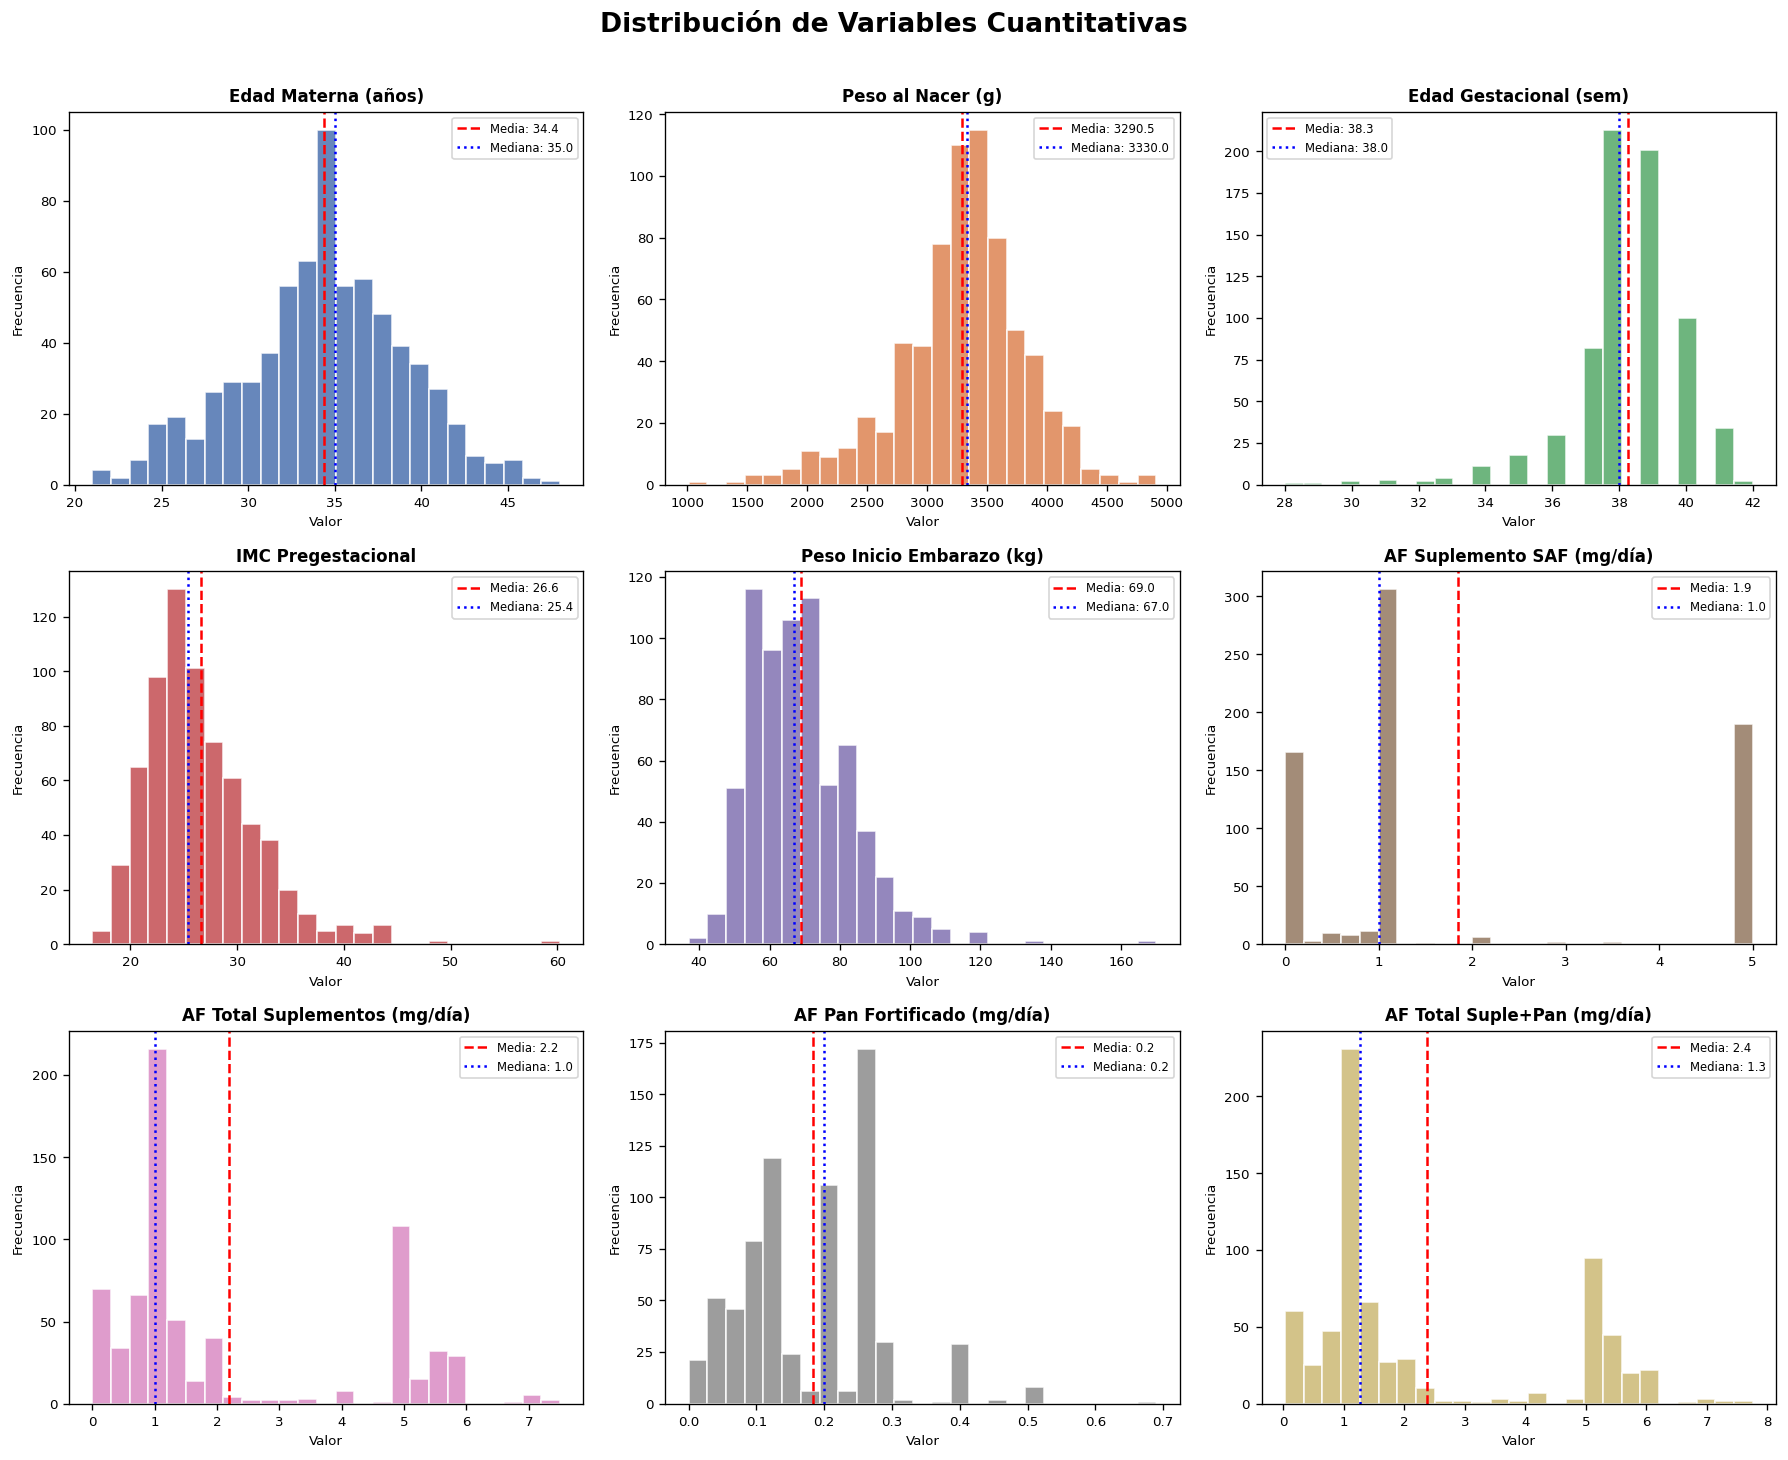

In [42]:
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52',
          '#8172B2','#937860','#DA8BC3','#8C8C8C','#CCB974']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribución de Variables Cuantitativas', fontsize=16, fontweight='bold', y=1.01)

for ax, col, label, color in zip(axes.flatten(), quant_cols, etiquetas, COLORS):
    data = df[col].dropna()
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',  linestyle='--', lw=1.5,
               label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='blue', linestyle=':',  lw=1.5,
               label=f'Mediana: {data.median():.1f}')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


### Boxplots y Valores Atípicos

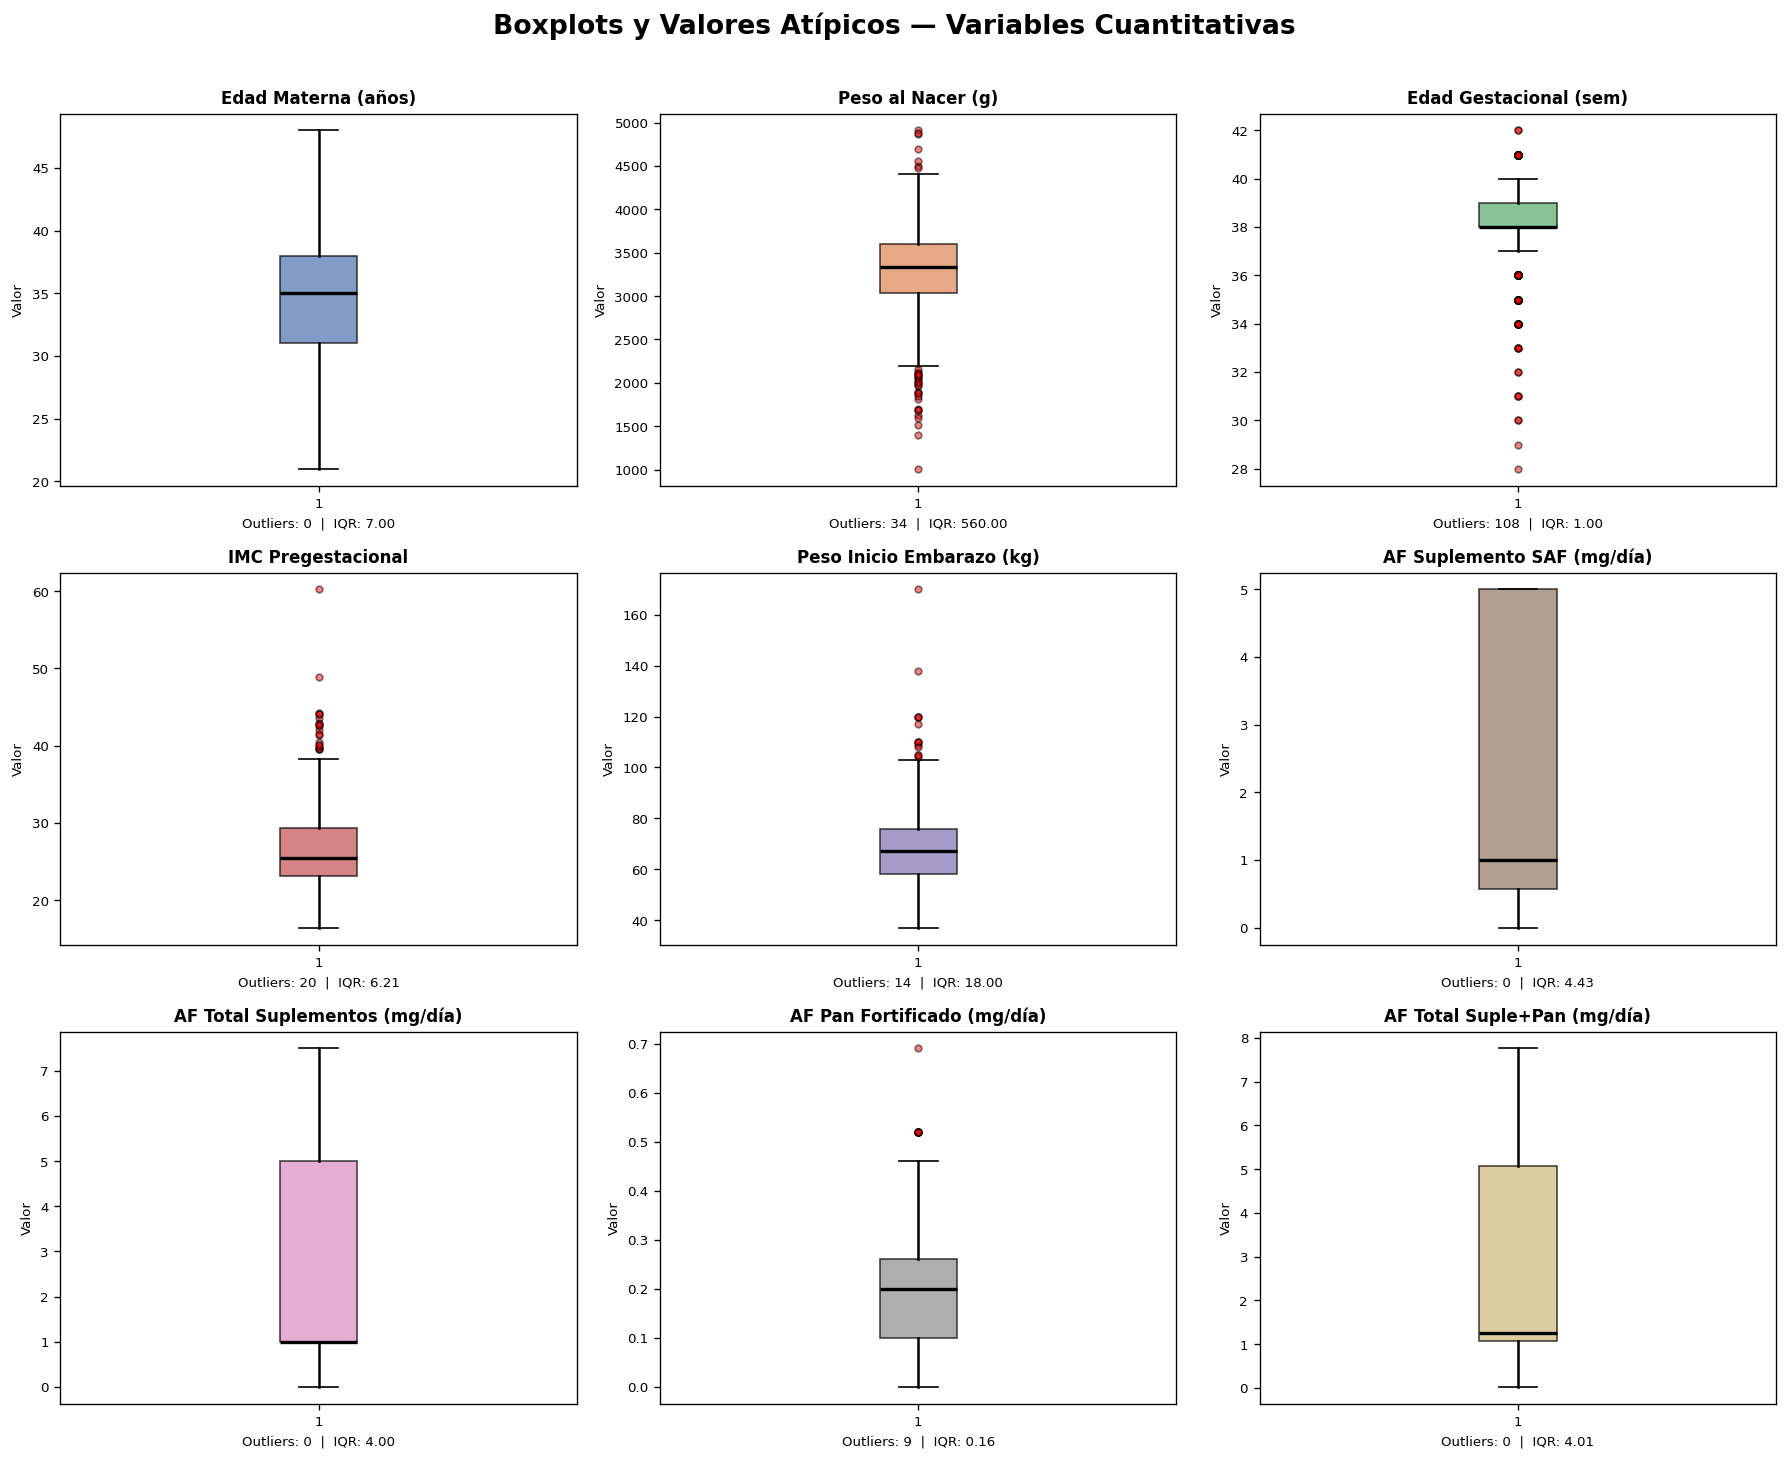

In [43]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Boxplots y Valores Atípicos — Variables Cuantitativas',
             fontsize=16, fontweight='bold', y=1.01)

for ax, col, label, color in zip(axes.flatten(), quant_cols, etiquetas, COLORS):
    data = df[col].dropna()
    bp = ax.boxplot(
        data, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.7),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5)
    )
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr    = q3 - q1
    nout   = int(((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum())
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Valor', fontsize=8)
    ax.set_xlabel(f'Outliers: {nout}  |  IQR: {iqr:.2f}', fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


### Mapa de Calor — Análisis de Correlación

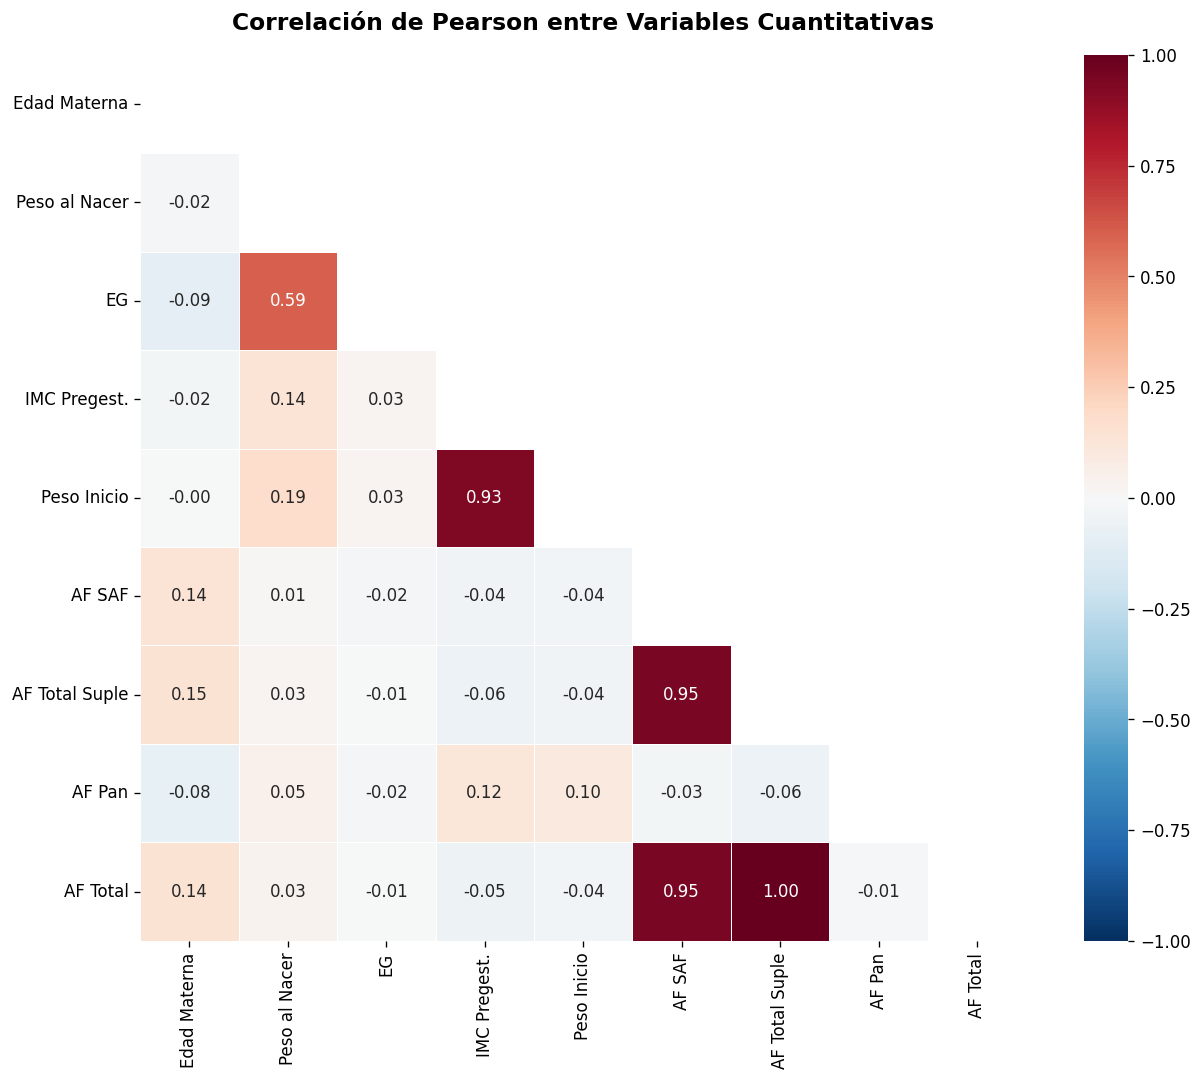

In [44]:
corr_labels = [
    'Edad Materna', 'Peso al Nacer', 'EG', 'IMC Pregest.',
    'Peso Inicio',  'AF SAF',        'AF Total Suple',
    'AF Pan',       'AF Total'
]

corr_matrix         = df[quant_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, annot_kws={'size': 10}, linewidths=0.5, square=True
)
ax.set_title('Correlación de Pearson entre Variables Cuantitativas',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


###  Distribución de Variables Categóricas

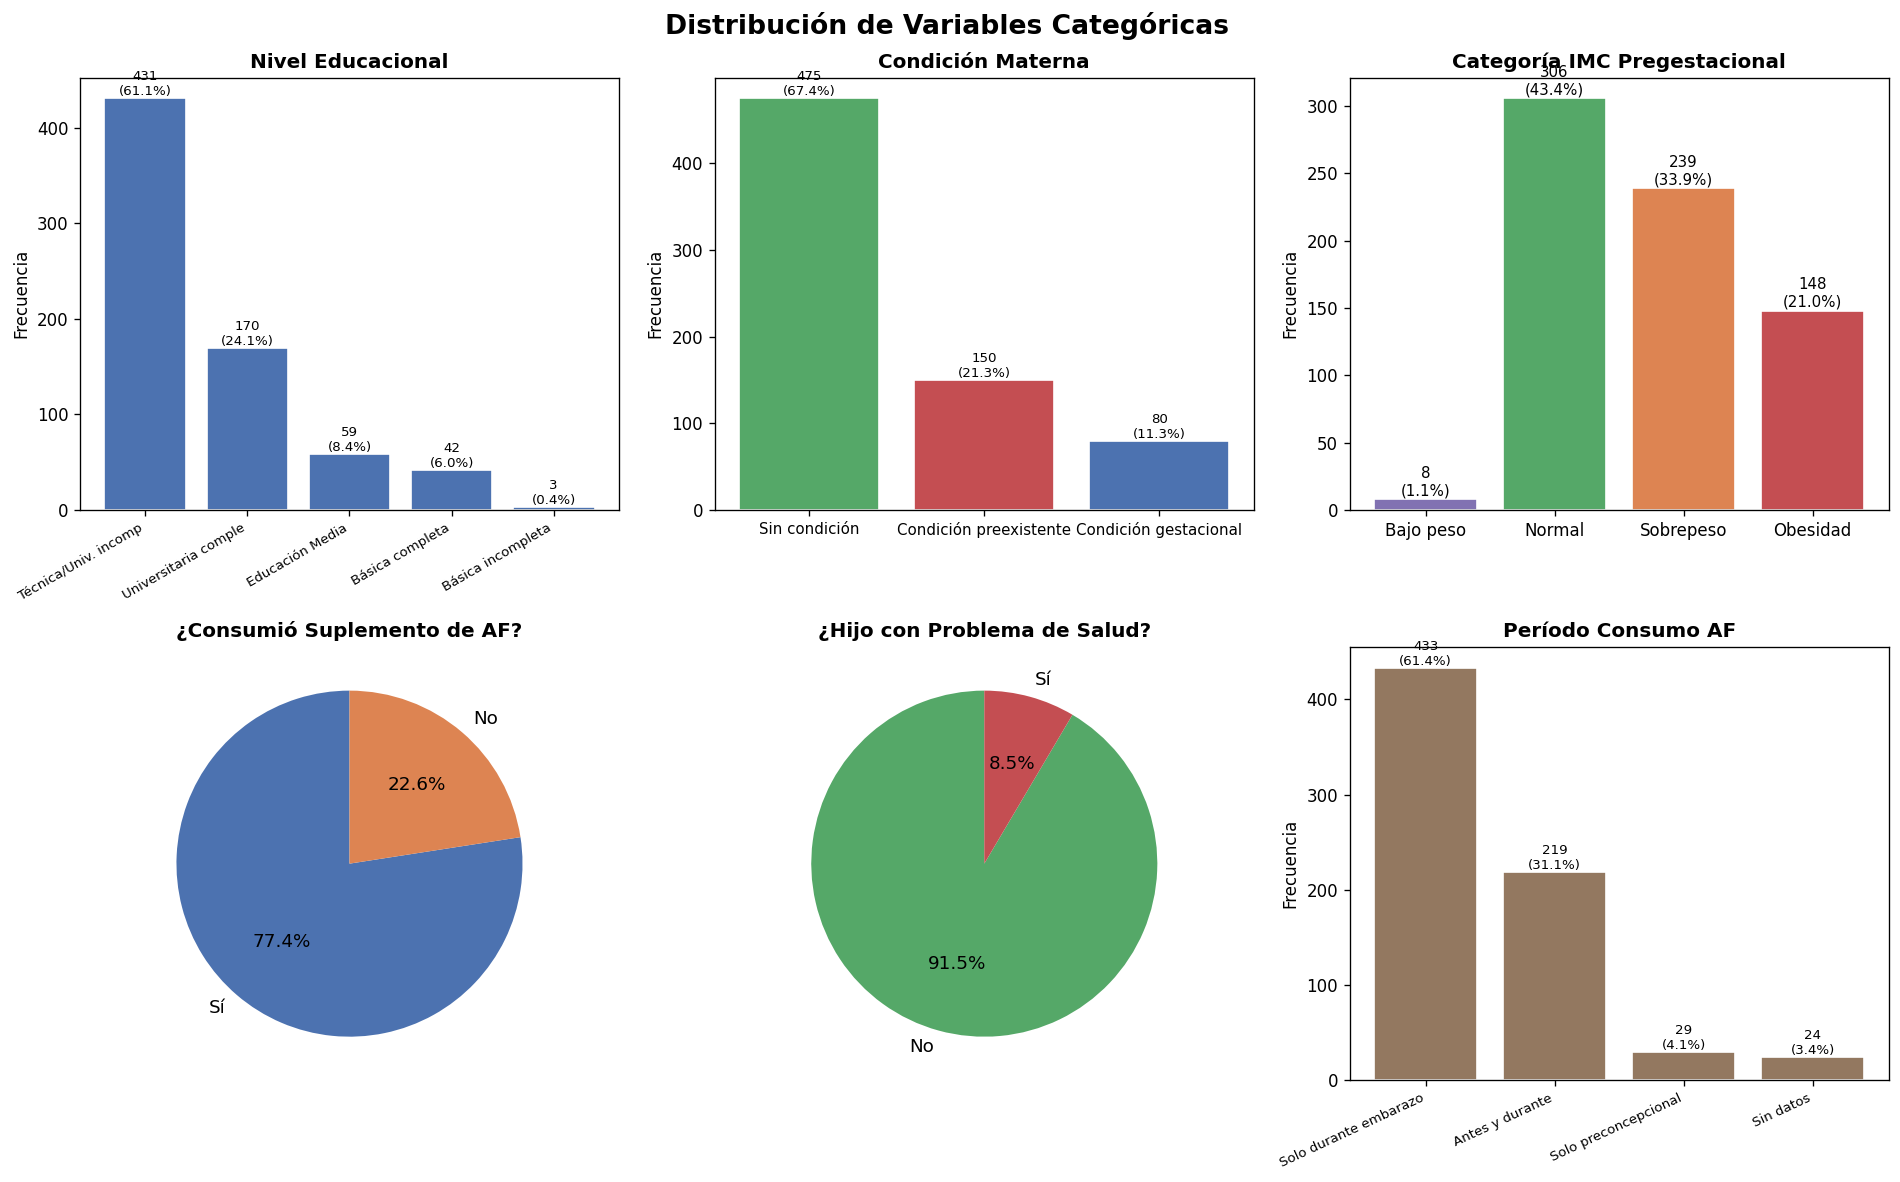

In [45]:
IMC_ORDER  = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']
IMC_COLORS = {'Bajo peso':'#8172B2', 'Normal':'#55A868',
              'Sobrepeso':'#DD8452',  'Obesidad':'#C44E52'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold')

# Educación
vc = df['Educación_nom'].value_counts()
axes[0,0].bar(range(len(vc)), vc.values, color='#4C72B0', edgecolor='white')
axes[0,0].set_xticks(range(len(vc)))
axes[0,0].set_xticklabels([t[:20] for t in vc.index], rotation=30, ha='right', fontsize=8)
axes[0,0].set_title('Nivel Educacional', fontweight='bold')
axes[0,0].set_ylabel('Frecuencia')
for i, v in enumerate(vc.values):
    axes[0,0].text(i, v+3, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

# Condición materna
vc = df['Condición_nom'].value_counts()
colors_cond = ['#55A868', '#C44E52', '#4C72B0']
axes[0,1].bar(vc.index, vc.values, color=colors_cond[:len(vc)], edgecolor='white')
axes[0,1].set_title('Condición Materna', fontweight='bold')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].tick_params(axis='x', labelsize=9)
for i, (k,v) in enumerate(vc.items()):
    axes[0,1].text(i, v+3, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

# IMC categoría
vc = df['IMC_cat'].value_counts().reindex(IMC_ORDER).dropna()
axes[0,2].bar(vc.index, vc.values,
              color=[IMC_COLORS[c] for c in vc.index], edgecolor='white')
axes[0,2].set_title('Categoría IMC Pregestacional', fontweight='bold')
axes[0,2].set_ylabel('Frecuencia')
for i, (k,v) in enumerate(vc.items()):
    axes[0,2].text(i, v+3, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Pie: consume SAF
vc = df['SAF_nom'].value_counts()
axes[1,0].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
              colors=['#4C72B0','#DD8452'], startangle=90,
              textprops={'fontsize':11})
axes[1,0].set_title('¿Consumió Suplemento de AF?', fontweight='bold')

# Pie: problema de salud RN
vc = df['Problema_nom'].value_counts()
axes[1,1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
              colors=['#55A868','#C44E52'], startangle=90,
              textprops={'fontsize':11})
axes[1,1].set_title('¿Hijo con Problema de Salud?', fontweight='bold')

# Período consumo AF
vc = df['Periodo_nom'].value_counts()
axes[1,2].bar(range(len(vc)), vc.values, color='#937860', edgecolor='white')
axes[1,2].set_xticks(range(len(vc)))
axes[1,2].set_xticklabels([t[:22] for t in vc.index], rotation=25, ha='right', fontsize=8)
axes[1,2].set_title('Período Consumo AF', fontweight='bold')
axes[1,2].set_ylabel('Frecuencia')
for i, (k,v) in enumerate(vc.items()):
    axes[1,2].text(i, v+3, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


### Relaciones Clave entre Variables

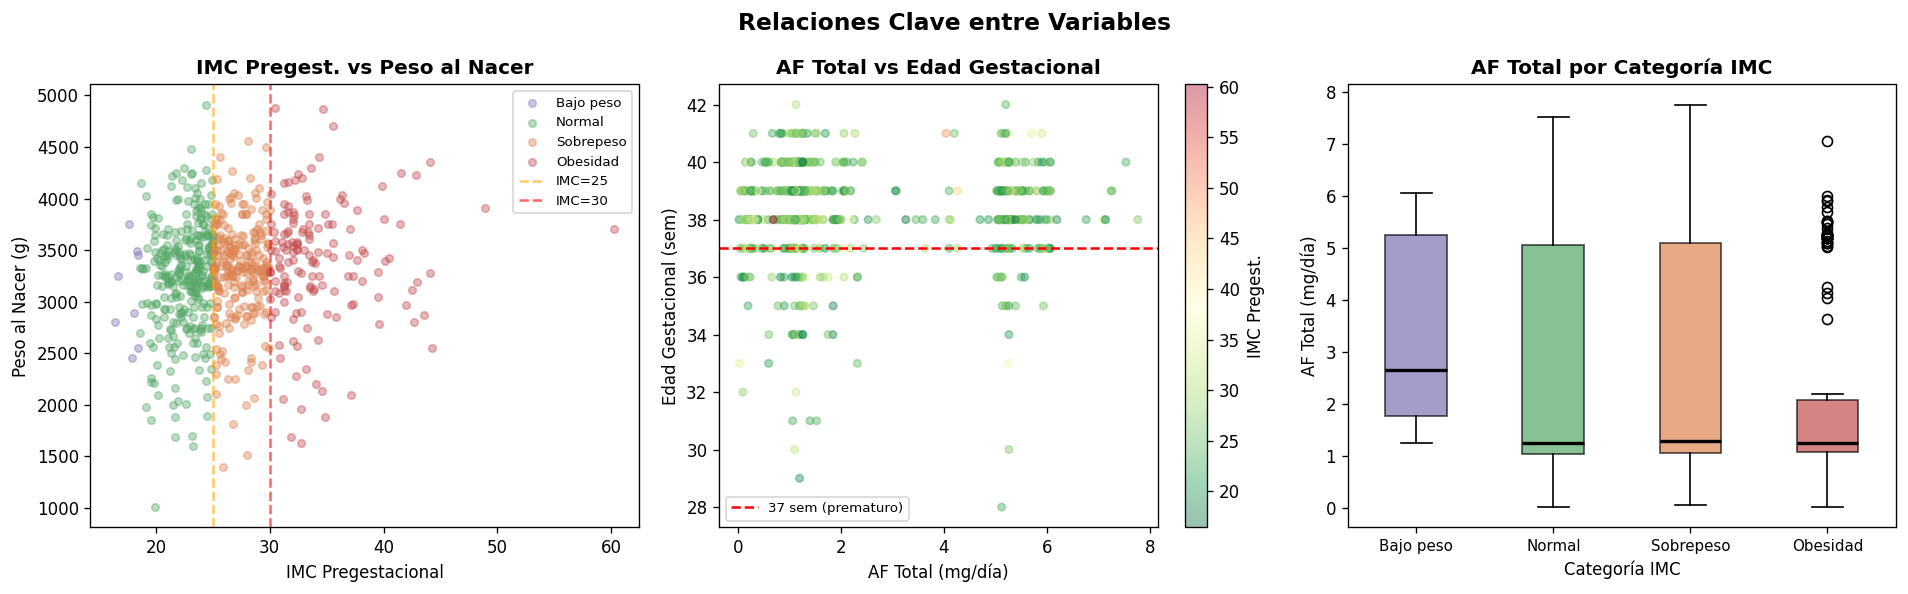

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Relaciones Clave entre Variables', fontsize=14, fontweight='bold')

# IMC vs Peso al nacer por categoría
for cat in IMC_ORDER:
    sub = df[df['IMC_cat'] == cat]
    if len(sub) > 0:
        axes[0].scatter(sub['IMC antes'], sub['PN hijo (g)'],
                        label=cat, color=IMC_COLORS[cat], alpha=0.4, s=20)
axes[0].axvline(25, color='orange', linestyle='--', alpha=0.6, label='IMC=25')
axes[0].axvline(30, color='red',    linestyle='--', alpha=0.6, label='IMC=30')
axes[0].set_xlabel('IMC Pregestacional', fontsize=10)
axes[0].set_ylabel('Peso al Nacer (g)', fontsize=10)
axes[0].set_title('IMC Pregest. vs Peso al Nacer', fontweight='bold')
axes[0].legend(fontsize=8)

# AF Total vs EG coloreado por IMC
sc = axes[1].scatter(
    df['Total mg/d AF  suple y pan'], df['EG hijo (sem)'],
    c=df['IMC antes'], cmap='RdYlGn_r', alpha=0.4, s=20
)
axes[1].axhline(37, color='red', linestyle='--', lw=1.5, label='37 sem (prematuro)')
axes[1].set_xlabel('AF Total (mg/día)', fontsize=10)
axes[1].set_ylabel('Edad Gestacional (sem)', fontsize=10)
axes[1].set_title('AF Total vs Edad Gestacional', fontweight='bold')
axes[1].legend(fontsize=8)
plt.colorbar(sc, ax=axes[1], label='IMC Pregest.')

# Boxplot AF Total por categoría IMC
data_box     = [df[df['IMC_cat']==cat]['Total mg/d AF  suple y pan'].dropna()
                for cat in IMC_ORDER if cat in df['IMC_cat'].values]
cats_present = [cat for cat in IMC_ORDER if cat in df['IMC_cat'].values]
bp = axes[2].boxplot(data_box, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, cat in zip(bp['boxes'], cats_present):
    patch.set_facecolor(IMC_COLORS[cat])
    patch.set_alpha(0.7)
axes[2].set_xticklabels(cats_present, fontsize=9)
axes[2].set_xlabel('Categoría IMC', fontsize=10)
axes[2].set_ylabel('AF Total (mg/día)', fontsize=10)
axes[2].set_title('AF Total por Categoría IMC', fontweight='bold')

plt.tight_layout()
plt.show()


---
## Verificación de Calidad de Datos

### Valores Faltantes


In [47]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
tbl_nulos = pd.DataFrame({
    'N° Nulos': nulos,
    '% del total': (nulos / len(df) * 100).round(2)
})
tbl_nulos


,N° Nulos,% del total
¿Cuántas cáp OSAF?,668,94.75
¿Cuántos días de OSAF?,668,94.75
mgAF/cáp OSAF,668,94.75
¿Cuántas cáp MAF?,339,48.09
¿Cuántos días de MAF?,338,47.94
¿Cuántos días de SAF?,137,19.43
¿Cuántas cáp SAF?,137,19.43
mgAF/cáp SAF+OSAF,97,13.76
mgAF/cáp MAF,30,4.26
mgAF/día período MAF,30,4.26


### 7.2 Duplicados

In [48]:
n_dup = df.duplicated().sum()
print(f"Filas duplicadas: {n_dup}  →  {'Sin duplicados' if n_dup == 0 else 'Revisar'}")


Filas duplicadas: 0  →  Sin duplicados


### Valores Extremos Clínicamente Inválidos

In [49]:
checks = [
    ('PN hijo (g)',    'Peso al nacer < 500 g (inviable)',     df['PN hijo (g)'] < 500),
    ('PN hijo (g)',    'Peso al nacer > 5,000 g (macrosomia)', df['PN hijo (g)'] > 5000),
    ('EG hijo (sem)',  'EG < 24 semanas (inviable)',           df['EG hijo (sem)'] < 24),
    ('IMC antes',      'IMC > 50 (obesidad extrema)',          df['IMC antes'] > 50),
    ('Edad madre',     'Edad materna < 15 años',               df['Edad madre'] < 15),
    ('Edad madre',     'Edad materna > 50 años',               df['Edad madre'] > 50),
]

rows = []
for col, desc, mask in checks:
    n    = int(mask.sum())
    flag = 'OK' if n == 0 else 'REVISAR'
    rows.append({'Descripción': desc, 'Variable': col, 'N° casos': n, 'Estado': flag})

pd.DataFrame(rows).set_index('Descripción')


,Variable,N° casos,Estado
Descripción,,,
Peso al nacer < 500 g (inviable),PN hijo (g),0,OK
"Peso al nacer > 5,000 g (macrosomia)",PN hijo (g),0,OK
EG < 24 semanas (inviable),EG hijo (sem),0,OK
IMC > 50 (obesidad extrema),IMC antes,1,REVISAR
Edad materna < 15 años,Edad madre,0,OK
Edad materna > 50 años,Edad madre,0,OK
